
B_R1s(r) =
+7.8685 * exp(-5.7531 r)
+6.8014 * exp(-3.7156 r)
-2.1352 * r^2 * exp(-9.9670 r)
+2.1976 * r^2 * exp(-3.7128 r)
+11.8519 * r * exp(-4.4661 r)
+0.0002 * r * exp(-1.2919 r)
-0.0000 * r * exp(-0.8555 r)

B_R2s(r) =
-0.4520 * exp(-5.7531 r)
-2.2212 * exp(-3.7156 r)
-0.5615 * r^2 * exp(-9.9670 r)
-2.4630 * r^2 * exp(-3.7128 r)
-1.5539 * r * exp(-4.4661 r)
+0.8498 * r * exp(-1.2919 r)
+0.5360 * r * exp(-0.8555 r)
Norm 1s = 0.9999996125600639
Norm 2s = 1.0001645702146178
           Q  J_1s_one_electron  J_2s_one_electron    J_total_Be
0       0.00       2.369961e-01       1.338390e+00  3.150773e+00
1       0.05       2.368524e-01       1.315659e+00  3.105022e+00
2       0.10       2.364223e-01       1.250125e+00  2.973094e+00
3       0.15       2.357079e-01       1.149185e+00  2.769785e+00
4       0.20       2.347126e-01       1.023409e+00  2.516244e+00
...      ...                ...                ...           ...
1996   99.80       7.354580e-10       2.437724e-11  1.519670e-09

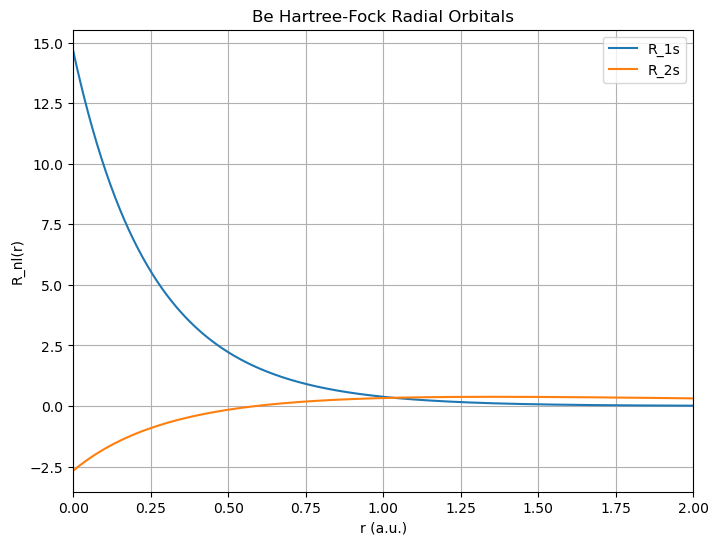

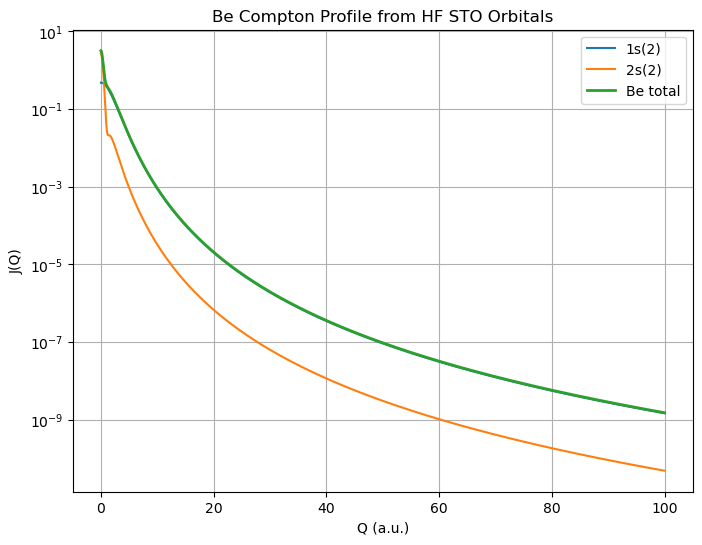

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Beryllium Hartree-Fock STO data
# Be: 1s2 2s2
# Ground term: 1S
# Format: (n_j, Z_j, C_j)
# =====================================================

# -------------------------
# Be 1s orbital
# -------------------------
beryllium_1s = [
    (1, 5.7531,  0.285107),
    (1, 3.7156,  0.474813),
    (3, 9.9670, -0.001620),

    (3, 3.7128,  0.052852),
    (2, 4.4661,  0.243499),
    (2, 1.2919,  0.000106),
    (2, 0.8555, -0.000032),
]

# -------------------------
# Be 2s orbital
# -------------------------
beryllium_2s = [
    (1, 5.7531, -0.016378),
    (1, 3.7156, -0.155066),
    (3, 9.9670, -0.000426),

    (3, 3.7128, -0.059234),
    (2, 4.4661, -0.031925),
    (2, 1.2919,  0.387968),
    (2, 0.8555,  0.685674),
]
# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, beryllium_1s)
R2s = R_nl(r, beryllium_2s)

print_R_formula(beryllium_1s, "B_R1s")
print_R_formula(beryllium_2s, "B_R2s")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))

# Be: 1s2 2s2 
J_total = 2*J_1s + 2*J_2s  

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_total_Be": J_total
    })
print(table)
table.to_csv("Be_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Be Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, J_total, label="Be total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Be Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()